# Fitting observed ΔΣ(R) with Dark Emulator

This notebook shows how to fit **galaxy-galaxy lensing** observational data (excess surface mass density ΔΣ(R)) using Dark Emulator and cloelike.

Workflow:
1. Prepare observational data (or mock data)
2. Set up the GGL likelihood with `EuclidLikelihood_DarkEmu_RealSpace`
3. Optimize (or run MCMC) to fit cosmology and HOD parameters

## 1. Path and imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

NOTEBOOK_DIR = Path.cwd()
CLOE_ROOT = NOTEBOOK_DIR.parent.parent.parent  # tutorials/dark_emulator -> CLOE
sys.path.insert(0, str(CLOE_ROOT / "cloelib"))
sys.path.insert(0, str(CLOE_ROOT / "cloelike"))
sys.path.insert(0, str(CLOE_ROOT / "dark_emulator_public"))

from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.cosmology.darkemu_cosmology import DarkEmuHODPerturbations
from cloelib.observables.darkemu_hod import DarkEmuHODParameters
from cloelike.EuclidLikelihood_DarkEmu_RealSpace import EuclidLikelihood_DarkEmu_RealSpace

print("CLOE_ROOT:", CLOE_ROOT)

CLOE_ROOT: /home/ryuseikano/Euclid/CLOE


## 2. Observational data

In this notebook we **generate mock data** in the format below for demonstration (fiducial cosmology + HOD + noise). You can replace the next cell with loading your own observed ΔΣ(R) and covariance.

**Data format (expected by the likelihood):**
- `delta_sigma`: observed ΔΣ [h M_sun / pc²]
- `R_bins`: projected radii [h⁻¹ Mpc]
- `z_lens`: lens redshift
- `covariance`: covariance matrix

In [2]:
# Fiducial parameters (for mock data; fix cosmology for a quick HOD-only fit if you prefer)
FIDUCIAL_COSMO = {
    "H0": 67.0,
    "Omega_cdm0": 0.27,
    "Omega_b0": 0.049,
    "Omega_k0": 0.0,
    "w0": -1.0,
    "wa": 0.0,
    "ns": 0.96,
    "As": 2.1e-9,
    "gamma_MG": 0.55,
    "mnu": 0.06,
    "N_mnu": 1,
}
FIDUCIAL_HOD = {
    "logMmin": 13.0,
    "sigma_sq": 0.3,
    "logM1": 14.0,
    "alpha": 1.0,
    "kappa": 1.0,
    "poff": 0.0,
    "Roff": 0.0,
}

# --- Mock observational data (replace with real data loading) ---
z_lens = 0.5
R_bins = np.logspace(-0.5, 1.5, 15)

background = CAMBBackground(**FIDUCIAL_COSMO)
hod_params = DarkEmuHODParameters(**FIDUCIAL_HOD)
pert = DarkEmuHODPerturbations(
    background=background,
    redshifts=np.array([z_lens]),
    hod_params=hod_params,
)
ds_fid = pert.delta_sigma(R_bins, z_lens)

np.random.seed(42)
noise_level = 0.1
sigma_ds = noise_level * np.abs(ds_fid)
cov_ds = np.diag(sigma_ds ** 2)
ds_obs = ds_fid + np.random.randn(len(R_bins)) * sigma_ds

data_ggl = {
    "delta_sigma": ds_obs,
    "R_bins": R_bins,
    "z_lens": z_lens,
    "covariance": cov_ds,
}
print("Mock GGL data: ", len(R_bins), " bins, z_lens =", z_lens)

/home/ryuseikano/Euclid/CLOE/cloelib/cloelib/cosmology/darkemu_cosmology.py:131: UserWarning: Neutrino density mismatch: input omega_nu = 0.000000, but Dark Emulator assumes fixed omega_nu = 0.00064. Dark Emulator will use its internal fixed value regardless of input.
  self.cparam = background_to_darkemu_cparam(background)


Mock GGL data:  15  bins, z_lens = 0.5


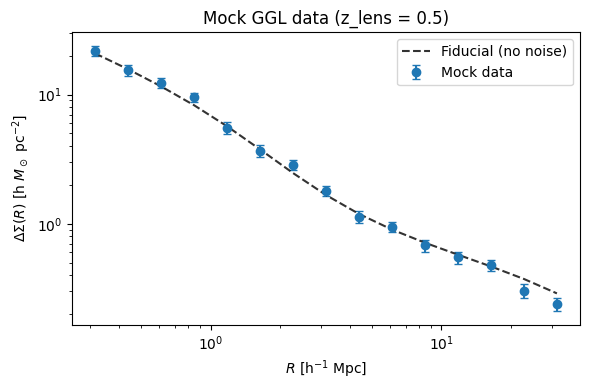

In [3]:
# Plot mock data: ΔΣ(R) with error bars; fiducial curve for reference
plt.figure(figsize=(6, 4))
plt.errorbar(R_bins, ds_obs, yerr=sigma_ds, fmt="o", capsize=3, label="Mock data")
plt.plot(R_bins, ds_fid, "k--", alpha=0.8, label="Fiducial (no noise)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$R$ [h$^{-1}$ Mpc]")
plt.ylabel(r"$\Delta\Sigma(R)$ [h $M_\odot$ pc$^{-2}$]")
plt.legend()
plt.title("Mock GGL data (z_lens = {})".format(z_lens))
plt.tight_layout()
plt.show()

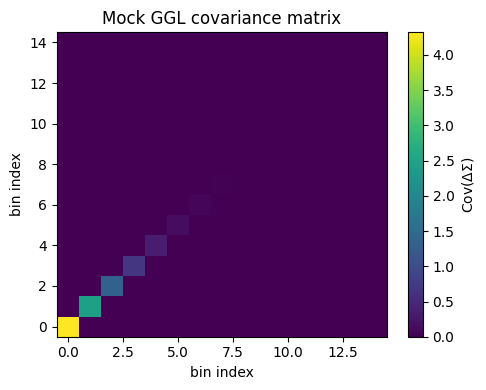

In [4]:
# Covariance matrix (diagonal for this mock; origin='lower' so small R at bottom)
plt.figure(figsize=(5, 4))
plt.imshow(cov_ds, aspect="auto", cmap="viridis", origin="lower")
plt.colorbar(label=r"$\mathrm{Cov}(\Delta\Sigma)$")
plt.xlabel("bin index")
plt.ylabel("bin index")
plt.title("Mock GGL covariance matrix")
plt.tight_layout()
plt.show()

## 3. Likelihood and scale cuts

In [5]:
settings = {
    # if you want to apply scale cuts
    # "R_min_ggl": 3.0,
    # "R_max_ggl": 30.0,
    "hod_params_fixed": {
        "kappa": FIDUCIAL_HOD["kappa"],
        "poff": FIDUCIAL_HOD["poff"],
        "Roff": FIDUCIAL_HOD["Roff"],
    },
}

likelihood = EuclidLikelihood_DarkEmu_RealSpace(
    data_ggl=data_ggl,
    settings=settings,
    Background=CAMBBackground,
)
print("Data points after scale cuts:", likelihood.n_ggl)

Data points after scale cuts: 15


## 4. Fitting

Minimize −log L (or chi²) over parameters. Here we fit HOD only with cosmology fixed.

It takes some time (~30mins).

In [6]:
def full_params_from_vector(x):
    """Map free parameters to full parameter dict."""
    return {
        **FIDUCIAL_COSMO,
        "logMmin": x[0],
        "sigma_sq": x[1],
        "logM1": x[2],
        "alpha": x[3],
        **settings["hod_params_fixed"],
    }

def neg_loglike(x):
    return -likelihood.loglike(full_params_from_vector(x))

# Initial guess (fiducial)
x0 = [FIDUCIAL_HOD["logMmin"], FIDUCIAL_HOD["sigma_sq"], FIDUCIAL_HOD["logM1"], FIDUCIAL_HOD["alpha"]]
bounds = [(12.0, 14.0), (0.05, 0.6), (13.0, 15.0), (0.5, 1.5)]

result = minimize(neg_loglike, x0, method="L-BFGS-B", bounds=bounds)
best = result.x
print("Best-fit HOD: logMmin = {:.3f}, sigma_sq = {:.3f}, logM1 = {:.3f}, alpha = {:.3f}".format(*best))
print("−log L at best fit:", result.fun)

Best-fit HOD: logMmin = 13.304, sigma_sq = 0.600, logM1 = 14.220, alpha = 1.500
−log L at best fit: 6.076134193113175


## 5. Plot: data vs best-fit theory

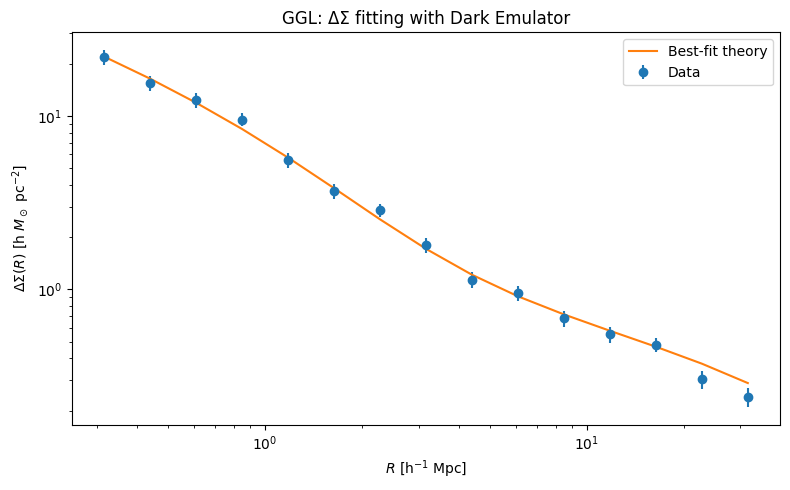

In [8]:
params_best = full_params_from_vector(best)
theory_full = likelihood.get_theory_vector(params_best)
theory_ggl = theory_full[likelihood.start_ggl : likelihood.start_ggl + likelihood.n_ggl]
R_plot = likelihood.R_bins_ggl
data_plot = likelihood.data_vector[likelihood.start_ggl : likelihood.start_ggl + likelihood.n_ggl]

# Use scale cuts if provided, otherwise use all R_bins (default: 0.0 to np.inf)
R_min = settings.get("R_min_ggl", 0.0)
R_max = settings.get("R_max_ggl", np.inf)
mask = (data_ggl["R_bins"] >= R_min) & (data_ggl["R_bins"] <= R_max)
cov_cut = np.asarray(data_ggl["covariance"])[np.outer(mask, mask)].reshape(mask.sum(), mask.sum())
sigma_plot = np.sqrt(np.diag(cov_cut))

plt.figure(figsize=(8, 5))
plt.errorbar(R_plot, data_plot, yerr=sigma_plot, fmt="o", label="Data")
plt.loglog(R_plot, theory_ggl, "-", label="Best-fit theory")
plt.xlabel(r"$R$ [h$^{-1}$ Mpc]")
plt.ylabel(r"$\Delta\Sigma(R)$ [h $M_\odot$ pc$^{-2}$]")
plt.legend()
plt.title("GGL: ΔΣ fitting with Dark Emulator")
plt.tight_layout()
plt.show()